In [2]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [3]:
# load the data
df = pd.read_csv('AusApparalSales4thQrt2020.csv')
df.head()

,Date,Time,State,Group,Unit,Sales
0,1-Oct-2020,Morning,WA,Kids,8,20000
1,1-Oct-2020,Morning,WA,Men,8,20000
2,1-Oct-2020,Morning,WA,Women,4,10000
3,1-Oct-2020,Morning,WA,Seniors,15,37500
4,1-Oct-2020,Afternoon,WA,Kids,3,7500


In [6]:
df.shape

(7560, 6)

In [4]:
print('The dataset contains {} rows and {} columns'.format(df.shape[0], df.shape[1]))

The dataset contains 7560 rows and 6 columns


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7560 entries, 0 to 7559
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    7560 non-null   object
 1   Time    7560 non-null   object
 2   State   7560 non-null   object
 3   Group   7560 non-null   object
 4   Unit    7560 non-null   int64 
 5   Sales   7560 non-null   int64 
dtypes: int64(2), object(4)
memory usage: 354.5+ KB


In [9]:
df.isna().sum()

Date     0
Time     0
State    0
Group    0
Unit     0
Sales    0
dtype: int64

In [9]:
# There are no null values in the dataset

In [12]:
# Convert the columns Time, State and Group from object datatype to string datatype so that we can use str related commands

In [26]:
df['Time'] = df['Time'].astype('string')
df['State'] = df['State'].astype('string')
df['Group'] = df['Group'].astype('string')

In [ ]:
# Convert the Date column to datetime


In [27]:
df['Date'] = pd.to_datetime(df['Date'])
df.head()

,Date,Time,State,Group,Unit,Sales,year,month,Weekday
0,2020-10-01,Morning,WA,Kids,8,20000,2020,10,3
1,2020-10-01,Morning,WA,Men,8,20000,2020,10,3
2,2020-10-01,Morning,WA,Women,4,10000,2020,10,3
3,2020-10-01,Morning,WA,Seniors,15,37500,2020,10,3
4,2020-10-01,Afternoon,WA,Kids,3,7500,2020,10,3


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7560 entries, 0 to 7559
Data columns (total 9 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Date     7560 non-null   datetime64[ns]
 1   Time     7560 non-null   string        
 2   State    7560 non-null   string        
 3   Group    7560 non-null   string        
 4   Unit     7560 non-null   int64         
 5   Sales    7560 non-null   int64         
 6   year     7560 non-null   int32         
 7   month    7560 non-null   int32         
 8   Weekday  7560 non-null   int32         
dtypes: datetime64[ns](1), int32(3), int64(2), string(3)
memory usage: 443.1 KB


In [24]:
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')
df.head()

,Date,Time,State,Group,Unit,Sales,year,month,Weekday
0,2020-10-01,Morning,WA,Kids,8,20000,2020,10,3
1,2020-10-01,Morning,WA,Men,8,20000,2020,10,3
2,2020-10-01,Morning,WA,Women,4,10000,2020,10,3
3,2020-10-01,Morning,WA,Seniors,15,37500,2020,10,3
4,2020-10-01,Afternoon,WA,Kids,3,7500,2020,10,3


In [29]:
df[ df.duplicated() ]

,Date,Time,State,Group,Unit,Sales,year,month,Weekday


In [22]:
print(df.duplicated().sum())

0


In [21]:
# Data Sanity checks


In [30]:
df.Time.unique()

<StringArray>
['Morning', 'Afternoon', 'Evening']
Length: 3, dtype: string

In [31]:
df.State.unique()

<StringArray>
['WA', 'NT', 'SA', 'VIC', 'QLD', 'NSW', 'TAS']
Length: 7, dtype: string

In [32]:
df.Group.unique()

<StringArray>
['Kids', 'Men', 'Women', 'Seniors']
Length: 4, dtype: string

In [33]:
# Lets correct the time column by removing the leading sapces.This will correct the whole column at once
df['Time'] = df['Time'].str.strip()
df.Time.unique()

<StringArray>
['Morning', 'Afternoon', 'Evening']
Length: 3, dtype: string

In [34]:
df['State'] = df['State'].str.strip()
df.State.unique()

<StringArray>
['WA', 'NT', 'SA', 'VIC', 'QLD', 'NSW', 'TAS']
Length: 7, dtype: string

In [35]:
df['Group'] = df['Group'].str.strip()
df.Group.unique()

<StringArray>
['Kids', 'Men', 'Women', 'Seniors']
Length: 4, dtype: string

In [39]:
# Lets correct the Group column by removing the leading space
df['Group'] = np.where(df['Group'] == ' Kids', 'Kids', df['Group'])
df['Group'] = np.where(df['Group'] == ' Men', 'Men', df['Group'])
df['Group'] = np.where(df['Group'] == ' Women', 'Women', df['Group'])
df['Group'] = np.where(df['Group'] == ' Seniors', 'Seniors', df['Group'])
df['Group'].unique()

array(['Kids', 'Men', 'Women', 'Seniors'], dtype=object)

In [40]:
df['Group'] = df['Group'].astype('string')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7560 entries, 0 to 7559
Data columns (total 9 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Date     7560 non-null   datetime64[ns]
 1   Time     7560 non-null   string        
 2   State    7560 non-null   string        
 3   Group    7560 non-null   string        
 4   Unit     7560 non-null   int64         
 5   Sales    7560 non-null   int64         
 6   year     7560 non-null   int32         
 7   month    7560 non-null   int32         
 8   Weekday  7560 non-null   int32         
dtypes: datetime64[ns](1), int32(3), int64(2), string(3)
memory usage: 443.1 KB


In [17]:
# remove space for complete dataset in a single go
# df = df.applymap(lambda x: x.strip() if isinstance(x, str) else x)

In [41]:
# Find the min and max values of the Unit and Sales column and print them
print("Min Unit:", df['Unit'].min())
print("Max Unit:", df['Unit'].max())
print("Min Sales:", df['Sales'].min())
print("Max Sales:", df['Sales'].max())

Min Unit: 2
Max Unit: 65
Min Sales: 5000
Max Sales: 162500


In [21]:
df[['Unit', 'Sales']].agg(['min', 'max'])

,Unit,Sales
min,2,5000
max,65,162500


In [8]:
# Outlier detection : View and Detect outliers in column 'Unit'



In [12]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unit,7560.0,18.005423,12.901403,2.0,8.0,14.0,26.0,65.0
Sales,7560.0,45013.558201,32253.506944,5000.0,20000.0,35000.0,65000.0,162500.0


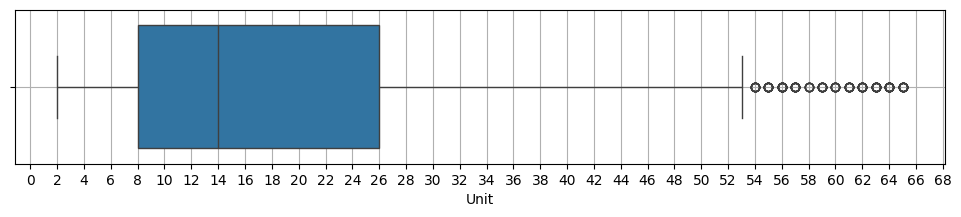

In [10]:
plt.figure(figsize=(12, 2))
sns.boxplot(x='Unit', data=df)
plt.xticks(range(0, 70, 2))
plt.grid()
plt.show()

In [11]:
Q1 = df['Unit'].describe().loc['25%']
Q3 = df['Unit'].describe().loc['75%']
print(Q1, Q3)

8.0 26.0


In [13]:
IQR = Q3 - Q1
lwrRange = Q1 - 1.5 * IQR
uprRange = Q3 + 1.5 * IQR
print(lwrRange, uprRange)

-19.0 53.0


In [16]:
df_unit = df[ (df['Unit'] < lwrRange) | (df['Unit'] > uprRange) ]
df_unit

,Date,Time,State,Group,Unit,Sales
5082,1-Dec-2020,Afternoon,VIC,Women,63,157500
5083,1-Dec-2020,Afternoon,VIC,Seniors,62,155000
5161,2-Dec-2020,Morning,VIC,Men,56,140000
5162,2-Dec-2020,Morning,VIC,Women,59,147500
5169,2-Dec-2020,Evening,VIC,Men,64,160000
...,...,...,...,...,...,...
7432,29-Dec-2020,Afternoon,VIC,Kids,65,162500
7433,29-Dec-2020,Afternoon,VIC,Men,54,135000
7437,29-Dec-2020,Evening,VIC,Men,54,135000
7515,30-Dec-2020,Morning,VIC,Seniors,65,162500


In [17]:
# option 1 : drop the rows where units are outliers
# df.drop( df[ (df.Unit < lwrRange) | (df.Unit > uprRange) ].index, inplace=True )

In [18]:
# Option 2: impute the unit column with mean values

unit_mean = df.describe().Unit['mean']

unit_mean = np.round(unit_mean, 1)

print(unit_mean)

18.0


In [19]:
# reading thru outliers dataframe and correcting the main dataframe
for row in df_unit.itertuples():

    df.at[row.Index, 'Unit'] = unit_mean

In [42]:
df.loc[5082]

Date       2020-12-01 00:00:00
Time                 Afternoon
State                      VIC
Group                    Women
Unit                        63
Sales                   157500
year                      2020
month                       12
Weekday                      1
Name: 5082, dtype: object

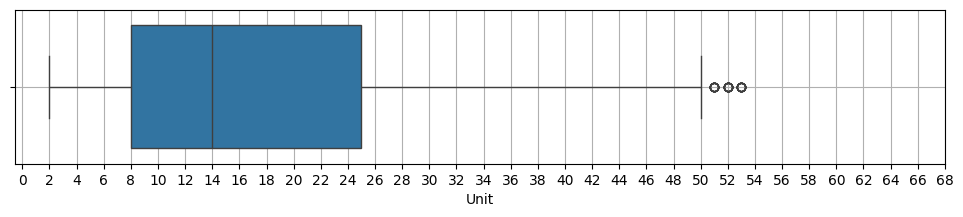

In [21]:
plt.figure(figsize=(12,2))

sns.boxplot(x = 'Unit', data = df)

plt.xticks(range(0,70,2))

plt.grid()

plt.show()

In [ ]:
# Can we set the outliers value to Q3 value instead of mean. 
# When we do this, we don't get any outliers in the new dataset.

In [23]:
# Find the Group that is making min and max sales
group_sales = df.groupby('Group').Sales.sum()
group_sales

Group
Kids       85072500
Men        85750000
Seniors    84037500
Women      85442500
Name: Sales, dtype: int64

In [25]:
print('Group with min sales: ', group_sales.idxmin(), '-', group_sales.min())
print('Group with max sales: ', group_sales.idxmax(), '-', group_sales.max())

Group with min sales:   Seniors - 84037500
Group with max sales:   Men - 85750000


In [28]:
fig = px.pie(values=group_sales, names=group_sales.index,
             color_discrete_sequence=px.colors.sequential.Blues,
             hole=0.4)
fig.update_traces(textposition='inside', textinfo='percent+value+label')
fig.show()

In [ ]:
#Find the state that is making min and max sales

In [29]:
state_sales = df.groupby('State').Sales.sum()
state_sales

State
NSW     74970000
NT      22580000
QLD     33417500
SA      58857500
TAS     22760000
VIC    105565000
WA      22152500
Name: Sales, dtype: int64

In [30]:
print('State with min sales: ', state_sales.idxmin(), '-', state_sales.min()) 
print('State with max sales: ', state_sales.idxmax(), '-', state_sales.max()) 

State with min sales:   WA - 22152500
State with max sales:   VIC - 105565000


In [32]:
fig = px.bar(x=state_sales.index, y=state_sales.values,
             color=state_sales.values,color_continuous_scale=px.colors.sequential.Blugrn, labels={"x": "State", "y": "Sales"},
             title="Sales by State", text=state_sales.values, width = 800, height = 400)
fig.update_traces(textposition="inside")
fig.show()

In [ ]:
# Monthwise sales

In [9]:
df['Date'] = pd.to_datetime(df['Date'], format='%d-%b-%Y')
df['year'] = df.Date.dt.year
df['month'] = df.Date.dt.month
df['Weekday'] = df.Date.dt.weekday
df.head()

,Date,Time,State,Group,Unit,Sales,year,month,Weekday
0,2020-10-01,Morning,WA,Kids,8,20000,2020,10,3
1,2020-10-01,Morning,WA,Men,8,20000,2020,10,3
2,2020-10-01,Morning,WA,Women,4,10000,2020,10,3
3,2020-10-01,Morning,WA,Seniors,15,37500,2020,10,3
4,2020-10-01,Afternoon,WA,Kids,3,7500,2020,10,3


In [37]:
month_sales = df.groupby('month').Sales.sum()
month_sales

month
10    114290000
11     90682500
12    135330000
Name: Sales, dtype: int64

In [38]:
print('Month with max sales: ', month_sales.idxmax(), '-', month_sales.max())

Month with max sales:  12 - 135330000


In [43]:
fig = px.pie(values=month_sales, names=month_sales.index,
             color_discrete_sequence=px.colors.sequential.Aggrnyl_r,
             hole=0.4)
fig.update_traces(textposition='inside', textinfo='percent+value+label')
fig.show()

In [45]:
month_map = {
    1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr',
    5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Aug',
    9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'
}

month_labels = month_sales.index.map(month_map)

fig = px.bar(x=month_labels, y=month_sales,
    labels={'x': 'Month', 'y': 'Sales'}
)

fig.update_traces(textposition="inside")
fig.show()

In [ ]:
# Vizualization

C:\Users\arunt\AppData\Local\Temp\ipykernel_25064\1810263812.py:1: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 0)` for the same effect.

  sns.catplot(x = 'Group', y = 'Sales', data = df, kind = 'bar', hue = 'State',


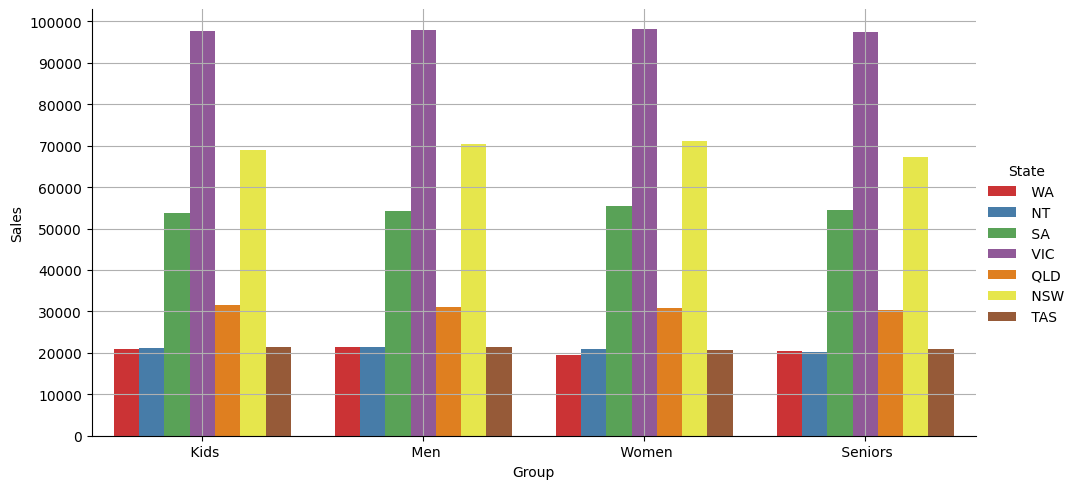

In [6]:
sns.catplot(x = 'Group', y = 'Sales', data = df, kind = 'bar', hue = 'State',
           height = 5, aspect = 2, palette = 'Set1', ci = 0)
plt.yticks(np.arange(0, 110000, 10000))
plt.grid()
plt.show()

In [7]:
# Reports

In [10]:
# Create a copy of the Dataframe
dfc = df.copy()
dfc.head()

,Date,Time,State,Group,Unit,Sales,year,month,Weekday
0,2020-10-01,Morning,WA,Kids,8,20000,2020,10,3
1,2020-10-01,Morning,WA,Men,8,20000,2020,10,3
2,2020-10-01,Morning,WA,Women,4,10000,2020,10,3
3,2020-10-01,Morning,WA,Seniors,15,37500,2020,10,3
4,2020-10-01,Afternoon,WA,Kids,3,7500,2020,10,3


In [48]:
dfc.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 7560 entries, 2020-10-01 to 2020-12-30
Data columns (total 8 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Time     7560 non-null   object
 1   State    7560 non-null   object
 2   Group    7560 non-null   object
 3   Unit     7560 non-null   int64 
 4   Sales    7560 non-null   int64 
 5   year     7560 non-null   int32 
 6   month    7560 non-null   int32 
 7   Weekday  7560 non-null   int32 
dtypes: int32(3), int64(2), object(3)
memory usage: 443.0+ KB


In [12]:
# Set the 'Date' column as the index of the Dataframe
dfc.set_index('Date', inplace=True)
dfc.head()

,Time,State,Group,Unit,Sales,year,month,Weekday
Date,,,,,,,,
2020-10-01,Morning,WA,Kids,8,20000,2020,10,3
2020-10-01,Morning,WA,Men,8,20000,2020,10,3
2020-10-01,Morning,WA,Women,4,10000,2020,10,3
2020-10-01,Morning,WA,Seniors,15,37500,2020,10,3
2020-10-01,Afternoon,WA,Kids,3,7500,2020,10,3


In [50]:
dfc['Time'] = dfc['Time'].astype('string')
dfc['State'] = dfc['State'].astype('string')
dfc['Group'] = dfc['Group'].astype('string')

In [51]:
dfc.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 7560 entries, 2020-10-01 to 2020-12-30
Data columns (total 8 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Time     7560 non-null   string
 1   State    7560 non-null   string
 2   Group    7560 non-null   string
 3   Unit     7560 non-null   int64 
 4   Sales    7560 non-null   int64 
 5   year     7560 non-null   int32 
 6   month    7560 non-null   int32 
 7   Weekday  7560 non-null   int32 
dtypes: int32(3), int64(2), string(3)
memory usage: 443.0 KB


In [52]:
monthly_report = dfc.resample('M').sum()['Sales'] # group by month
quaterly_report = dfc.resample('Q').sum()['Sales'] # group by quarter

C:\Users\arunt\AppData\Local\Temp\ipykernel_25064\3751711347.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_report = dfc.resample('M').sum()['Sales'] # group by month
C:\Users\arunt\AppData\Local\Temp\ipykernel_25064\3751711347.py:2: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  quaterly_report = dfc.resample('Q').sum()['Sales'] # group by quarter


In [53]:
monthly_report

Date
2020-10-31    114290000
2020-11-30     90682500
2020-12-31    135330000
Freq: ME, Name: Sales, dtype: int64

In [54]:
quaterly_report

Date
2020-12-31    340302500
Freq: QE-DEC, Name: Sales, dtype: int64

In [55]:
daily_report = dfc.resample('D').sum()['Sales'] # group by daily
daily_report

Date
2020-10-01    3720000
2020-10-02    3715000
2020-10-03    3890000
2020-10-04    3720000
2020-10-05    3862500
               ...   
2020-12-26    4715000
2020-12-27    4637500
2020-12-28    4595000
2020-12-29    4607500
2020-12-30    4590000
Freq: D, Name: Sales, Length: 91, dtype: int64

C:\Users\arunt\AppData\Local\Temp\ipykernel_25064\637514336.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x= ['Oct', 'Nov', 'Dec'], y=monthly_report.values, palette='hls')


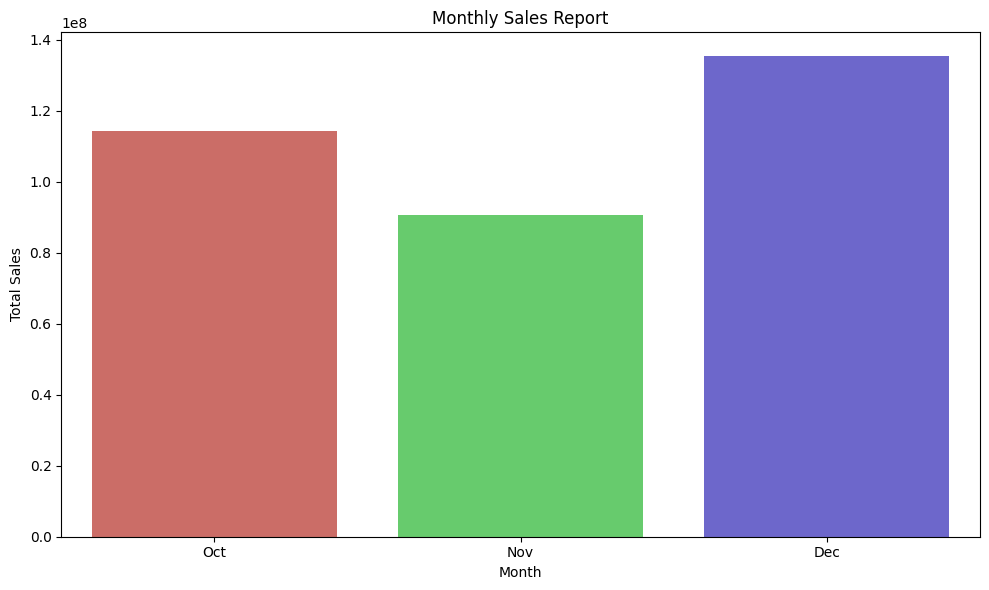

In [58]:
plt.figure(figsize=(10, 6))
sns.barplot(x= ['Oct', 'Nov', 'Dec'], y=monthly_report.values, palette='hls')
plt.title('Monthly Sales Report')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()

In [60]:
fig = px.scatter(
    x=daily_report.index,
    y=daily_report.values,
    labels={'x': 'Date', 'y': 'Sales'},
    title='Daily Sales Report'
)
# Optional: connect points with a line
fig.update_traces(mode='lines+markers')

fig.show()